In [1]:
import utils as ut
from torch.utils.data import DataLoader

2025-01-22 09:06:17.405585: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-22 09:06:17.558562: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737533177.628475 1320152 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737533177.652909 1320152 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-22 09:06:17.812859: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Vgg ready


In [2]:
import torch
import siamese_models as sm

vgg_path = '/home/arnaud/projects/symbrain_siamese/code/models/VGGNet_s5.pt'
resnet_path = '/home/arnaud/projects/symbrain_siamese/code/models/ResNet_s5.pt'

# load model architecture
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
vggnet_s5 = sm.SiameseNetworkVGGnet().to(device)  # Use the correct model class
vggnet_s5.load_state_dict(torch.load(vgg_path))
vggnet_s5.eval()

resnet_s5 = sm.SiameseNetworkResnet().to(device)  # Use the correct model class
resnet_s5.load_state_dict(torch.load(resnet_path))
resnet_s5.eval()

print("load ok")

/tmp/ipykernel_1320152/911942893.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vggnet_s5.load_state_dict(torch.load(vgg_path))


load ok


/tmp/ipykernel_1320152/911942893.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet_s5.load_state_dict(torch.load(resnet_path))


In [6]:
# Assume ds_folds[0]['test'] is your test dataset
ds_folds = ut.siamese_noise_dataset_fold_range(test_size=0.1, noise_size=5, n_splits=2)
test_loader = DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=32, shuffle=False)

Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674


In [24]:
iter(test_loader)[0]

TypeError: '_SingleProcessDataLoaderIter' object is not subscriptable

In [19]:
# print(next(iter(test_loader)).keys())
[(i,j.shape) for i,j in zip(next(iter(test_loader)).keys(), next(iter(test_loader)).values())]

[('slice1', torch.Size([32, 1, 224, 224])),
 ('slice2', torch.Size([32, 1, 224, 224])),
 ('label', torch.Size([32])),
 ('image_type', torch.Size([32]))]

In [9]:
ds_folds[0]['valid'][0]

{'slice1': <PIL.PngImagePlugin.PngImageFile image mode=L size=224x224>,
 'slice2': <PIL.PngImagePlugin.PngImageFile image mode=L size=224x224>,
 'label': 0,
 'image_type': 0}

In [ ]:
test_loader = DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=1, shuffle=False)
for i, batch in enumerate(test_loader):
    images_1 = batch['slice1'].to(device, dtype=torch.float32)
    images_2 = batch['slice2'].to(device, dtype=torch.float32)
    targets = batch['label'].to(device, dtype=torch.float32)
    if targets.item() == 0:
        display(ds_folds[0]['test']['slice1'][i])
        display(ds_folds[0]['test']['slice2'][i])
    # print("next")

In [9]:
ds_folds = ut.siamese_noise_dataset_fold_range(test_size=0.1, noise_size=7, n_splits=2)

Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674


16


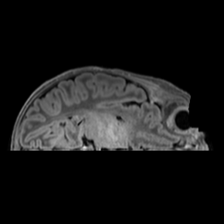

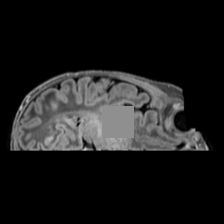

67


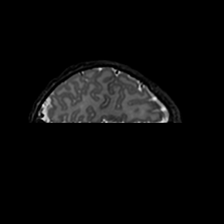

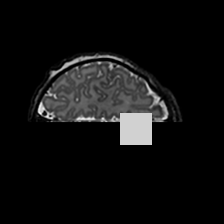

101


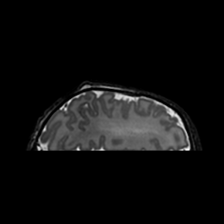

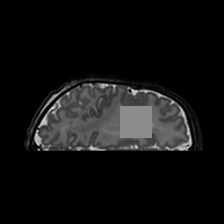

150


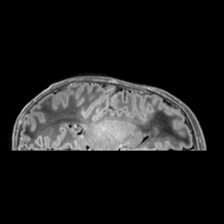

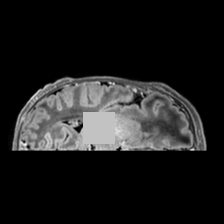

198


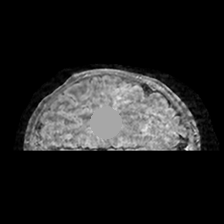

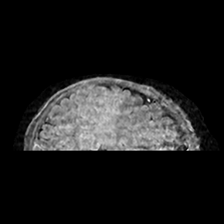

284


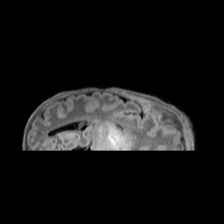

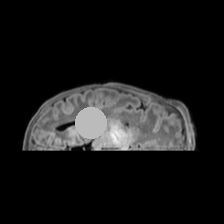

6
268
258


In [10]:
test_loader = DataLoader(ds_folds[0]['test'].with_format("torch"), batch_size=1, shuffle=False)
n=0
n_goods_res, n_goods_vgg = 0, 0
for i, batch in enumerate(test_loader):
    images_1 = batch['slice1'].to(device, dtype=torch.float32)
    images_2 = batch['slice2'].to(device, dtype=torch.float32)
    targets = batch['label'].to(device, dtype=torch.float32)
    outputs_vgg = vggnet_s5(images_1, images_2).squeeze()
    outputs_res = resnet_s5(images_1, images_2).squeeze()
    # print(targets, (outputs > 0.5).float())
    lbl_vgg = (outputs_vgg > 0.5).float().item()
    lbl_res = (outputs_res > 0.5).float().item()
    # select only noise 
    if targets.item() == lbl_res:
        n_goods_res += 1
    if targets.item() == lbl_vgg:
        n_goods_vgg += 1
    if targets.item() == 1:
        if lbl_vgg != lbl_res and targets.item() == lbl_vgg : # vgg ok but not res
            print(i)
            display(ds_folds[0]['test']['slice1'][i])
            display(ds_folds[0]['test']['slice2'][i])
            n+=1
print(n)

print(n_goods_res)
print(n_goods_vgg)

In [11]:
268/316

0.8481012658227848

In [8]:
# n bad cases
len(ds_folds[0]['test']['slice1']) 

# when noise at 2, resnet detects 19, vgg detects 54.

316

Other inputs

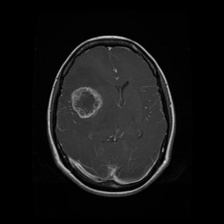

In [23]:
import PIL
sample31 = PIL.Image.open("sample31.jpg")
sample14 = PIL.Image.open("sample14.jpg")
sample31.resize((224,224))
sample14.resize((224,224))

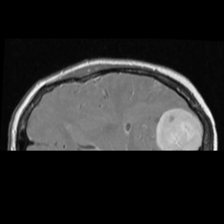

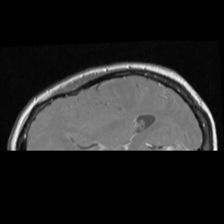

In [20]:
line ="[{'x': 30.53, 'y': 137.73} {'x': 246.75, 'y': 147.18}]"
hemi1, hemi2 = ut.cut_align(sample31.resize((290,290)).rotate(90, PIL.Image.NEAREST, expand = 1), line=line, show = True)
# hemi1, hemi2 = ut.cut_align(sample.resize((224,224)), line=line, show = True)
display(hemi1)
display(hemi2)

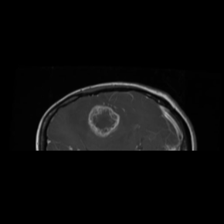

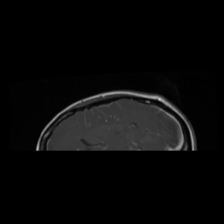

In [24]:
line ="[{'x': 30.53, 'y': 137.73} {'x': 246.75, 'y': 147.18}]"
hemi1_14, hemi2_14 = ut.cut_align(sample14.resize((290,290)).rotate(90, PIL.Image.NEAREST, expand = 1), line=line, show = True)
display(hemi1_14)
display(hemi2_14)

In [25]:
hemi1.size, hemi1_14.size

((224, 224), (224, 224))

In [27]:
from datasets import DatasetDict, Dataset
from torch.utils.data import DataLoader

fold_sampel = Dataset.from_dict({
        'slice1': [hemi1],
        'slice2': [hemi2],
        'label': [1],
        'image_type': [0]
    })
fold_sampel_14 = Dataset.from_dict({
        'slice1': [hemi1_14],
        'slice2': [hemi2_14],
        'label': [1],
        'image_type': [1]
})
sample_loader = DataLoader(fold_sampel.with_format("torch"), batch_size=1, shuffle=False)
sample_loader_14 = DataLoader(fold_sampel_14.with_format("torch"), batch_size=1, shuffle=False)

In [ ]:
for i, batch in enumerate(sample_loader):
    images_1 = batch['slice1'].to(device, dtype=torch.float32)
    images_2 = batch['slice2'].to(device, dtype=torch.float32)
    targets = batch['label'].to(device, dtype=torch.float32)
    outputs_vgg = vggnet_s5(images_1, images_2).squeeze()
    outputs_res = resnet_s5(images_1, images_2).squeeze()
    # print(targets, (outputs > 0.5).float())
    print(outputs_vgg, outputs_res)
    lbl_vgg = (outputs_vgg > 0.5).float().item()
    lbl_res = (outputs_res > 0.5).float().item()
    print(f"{lbl_vgg}")
    print(f"{lbl_res}")
    # select only noise 
    if targets.item() == 1:
        if lbl_vgg != lbl_res and targets.item() == lbl_vgg : # vgg ok but not res
            print(i)
            display(ds_folds[0]['test']['slice1'][i])
            display(ds_folds[0]['test']['slice2'][i])
    # print("next")

tensor(0.9402, device='cuda:0', grad_fn=<SqueezeBackward0>) tensor(0.7390, device='cuda:0', grad_fn=<SqueezeBackward0>)
1.0
1.0


In [30]:
for i, batch in enumerate(sample_loader_14):
    images_1 = batch['slice1'].to(device, dtype=torch.float32)
    images_2 = batch['slice2'].to(device, dtype=torch.float32)
    targets = batch['label'].to(device, dtype=torch.float32)
    outputs_vgg = vggnet_s5(images_1, images_2).squeeze()
    outputs_res = resnet_s5(images_1, images_2).squeeze()
    # print(targets, (outputs > 0.5).float())
    print(outputs_vgg, outputs_res)
    lbl_vgg = (outputs_vgg > 0.5).float().item()
    lbl_res = (outputs_res > 0.5).float().item()
    print(f"{lbl_vgg}")
    print(f"{lbl_res}")
    # select only noise 
    if targets.item() == 1:
        if lbl_vgg != lbl_res and targets.item() == lbl_vgg : # vgg ok but not res
            print(i)
            display(ds_folds[0]['test']['slice1'][i])
            display(ds_folds[0]['test']['slice2'][i])
    # print("next")

tensor(0.8419, device='cuda:0', grad_fn=<SqueezeBackward0>) tensor(0.7823, device='cuda:0', grad_fn=<SqueezeBackward0>)
1.0
1.0


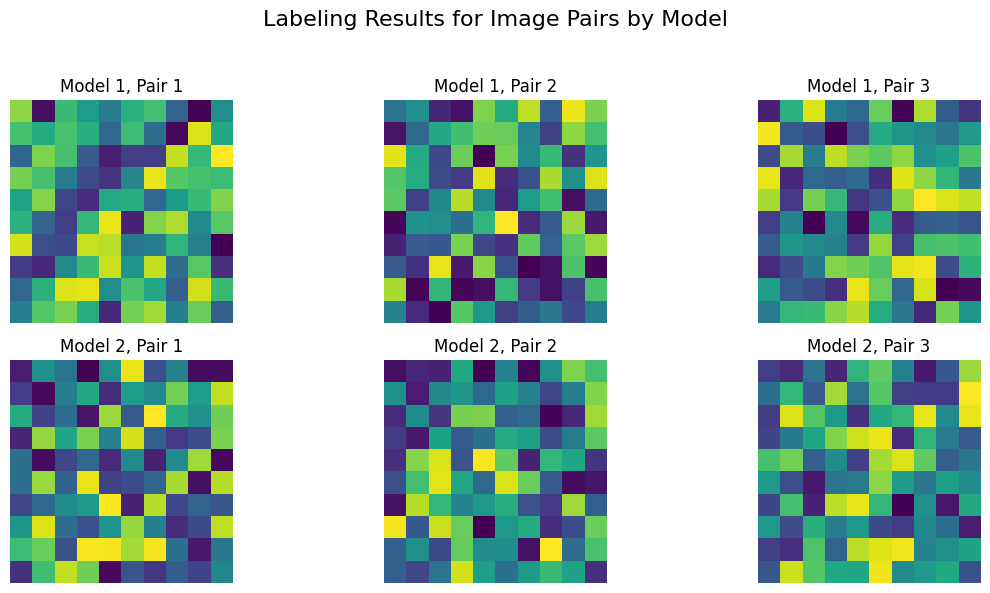

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated data for demonstration purposes
# Replace these arrays with your actual images or labeled results
image_pairs = [
    [np.random.rand(10, 10), np.random.rand(10, 10)],  # Pair 1
    [np.random.rand(10, 10), np.random.rand(10, 10)],  # Pair 2
    [np.random.rand(10, 10), np.random.rand(10, 10)],  # Pair 3
]

# Models
models = ['Model 1', 'Model 2']

# Create the figure and axes
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, model in enumerate(models):  # Rows for models
    for j, pair in enumerate(image_pairs):  # Columns for pairs
        # Plot the image for the current pair and model
        axes[i, j].imshow(pair[i], cmap='viridis')
        axes[i, j].set_title(f"{model}, Pair {j+1}")
        axes[i, j].axis('off')  # Turn off axes for a cleaner look

# Add a general title and adjust layout
plt.suptitle("Labeling Results for Image Pairs by Model", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
